***MULTIVARIATE REGRESSION MODELS***

In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
aqf_data=pd.read_csv("/content/AirQualityUCI.csv")
print(aqf_data.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6       1360.0     150.0      11.9   
1  3/10/2004  19:00:00     2.0       1292.0     112.0       9.4   
2  3/10/2004  20:00:00     2.2       1402.0      88.0       9.0   
3  3/10/2004  21:00:00     2.2       1376.0      80.0       9.2   
4  3/10/2004  22:00:00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  Unnamed: 15  Unnamed: 16  
0  13.6  48.9  0.7578          NaN          NaN  
1  13.3  47.7  0.7255 

In [ ]:
aqf_data.replace(-200,np.nan,inplace=True)
aqf_data.dropna(how='all',axis=0, inplace=True)
aqf_data.dropna(how='all',axis=1, inplace=True)
print(aqf_data.isnull().sum())
print(aqf_data.head())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6       1360.0     150.0      11.9   
1  3/10/2004  19:00:00     2.0       1292.0     112.0       9.4   
2  3/10/2004  20:00:00     2.2       1402.0      88.0       9.0   
3  3/10/2004  21:00:00     2.2       1376.0      80.0       9.2   
4  3/10/2004  22:00:00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0 

In [ ]:
x=aqf_data[["PT08.S1(CO)","PT08.S2(NMHC)","PT08.S3(NOx)","PT08.S5(O3)","T","RH","AH"]]
y=aqf_data[["CO(GT)"]]
print(x.head())
print(y.head())

   PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S5(O3)     T    RH      AH
0       1360.0         1046.0        1056.0       1268.0  13.6  48.9  0.7578
1       1292.0          955.0        1174.0        972.0  13.3  47.7  0.7255
2       1402.0          939.0        1140.0       1074.0  11.9  54.0  0.7502
3       1376.0          948.0        1092.0       1203.0  11.0  60.0  0.7867
4       1272.0          836.0        1205.0       1110.0  11.2  59.6  0.7888
   CO(GT)
0     2.6
1     2.0
2     2.2
3     2.2
4     1.6


In [ ]:
# Impute NaN values in x and y using their means
x.fillna(x.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)
x.isnull().sum().sum()
y.isnull().sum().sum()

/tmp/ipykernel_5226/1138348764.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.fillna(x.mean(), inplace=True)
/tmp/ipykernel_5226/1138348764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.fillna(y.mean(), inplace=True)


np.int64(0)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

***REGRESSION BASELINES***

In [ ]:
models={
        Ridge(),
        RandomForestRegressor(n_estimators=100,random_state=42),
        XGBRegressor(n_estimators=100,learning_rate=0.5,random_state=42)
}

In [ ]:
x_train.fillna(x_train.mean(), inplace=True)
y_train.fillna(y_train.mean(), inplace=True)

x_test.fillna(x_train.mean(), inplace=True)
y_test.fillna(y_train.mean(), inplace=True)

for model in models:
  model.fit(x_train, y_train.values.ravel())
  pred=model.predict(x_test)
print(pred)

[1.37884651 1.15389552 2.9496667  ... 1.1195564  2.37514864 2.11543725]


In [ ]:
rmse=mean_squared_error(y_test,pred)
mae=mean_absolute_error(y_test,pred)
r2=r2_score(y_test,pred)
print("Root Mean Squared Error: ",rmse)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",r2)


Root Mean Squared Error:  0.5822002110780263
Mean Absolute Error:  0.5052404879755537
R2 Score:  0.6864097495824852


In [ ]:
import joblib
from xgboost import XGBRegressor
xgboost_model = None
for model in models:
    if isinstance(model, XGBRegressor):
        xgboost_model = model
        break
if xgboost_model is not None:
    joblib.dump(xgboost_model, 'xgboost_aqi_model.pkl')
    print("Successfully found and saved your trained XGBoost model!")
else:
    print(" Could not find an XGBoost model in your models set.")

Successfully found and saved your trained XGBoost model!


***DEEP LEARNING MODEL***

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D,MaxPooling1D,LSTM,Bidirectional,Dense,Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
feature_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S5(O3)", "T", "RH", "AH"]
target_col = "CO(GT)"

In [ ]:
print(x.values)
print(y.values)

[[1.360e+03 1.046e+03 1.056e+03 ... 1.360e+01 4.890e+01 7.578e-01]
 [1.292e+03 9.550e+02 1.174e+03 ... 1.330e+01 4.770e+01 7.255e-01]
 [1.402e+03 9.390e+02 1.140e+03 ... 1.190e+01 5.400e+01 7.502e-01]
 ...
 [1.142e+03 1.063e+03 6.030e+02 ... 2.690e+01 1.830e+01 6.406e-01]
 [1.003e+03 9.610e+02 7.020e+02 ... 2.830e+01 1.350e+01 5.139e-01]
 [1.071e+03 1.047e+03 6.540e+02 ... 2.850e+01 1.310e+01 5.028e-01]]
[[2.6]
 [2. ]
 [2.2]
 ...
 [2.4]
 [2.1]
 [2.2]]


In [ ]:
Scaler_X=MinMaxScaler()
Scaler_Y=MinMaxScaler()
X_scaled = Scaler_X.fit_transform(x_train)
joblib.dump(Scaler_X, 'scaler_X.pkl')
Y_scaled=Scaler_Y.fit_transform(y_train.values.reshape(-1, 1))
print(X_scaled)
print(Y_scaled)


[[0.32507765 0.30374297 0.21748988 ... 0.43479202 0.50357485 0.41090274]
 [0.2275664  0.16876024 0.36171114 ... 0.2688172  0.61006289 0.26951082]
 [0.18521177 0.14472966 0.2901313  ... 0.18709677 0.4        0.10873283]
 ...
 [0.56927495 0.56198798 0.07285049 ... 0.52688172 0.65660377 0.72315887]
 [0.55348169 0.49098853 0.15205421 ... 0.45376344 0.33333333 0.2921859 ]
 [0.56353195 0.44347351 0.07920373 ... 0.32688172 0.59119497 0.32746909]]
[[0.27966102]
 [0.09322034]
 [0.09322034]
 ...
 [0.29661017]
 [0.33050847]
 [0.31355932]]


In [ ]:
lookback=24
x_sequences=[]
y_targets=[]
for i in range(lookback,len(X_scaled)):
  x_sequences.append(X_scaled[i-lookback:i])
x_sequences=np.array(x_sequences)
y_targets=np.array(Y_scaled[lookback:])
print(x_sequences)
print(y_targets)

[[[0.32507765 0.30374297 0.21748988 ... 0.43479202 0.50357485 0.41090274]
  [0.2275664  0.16876024 0.36171114 ... 0.2688172  0.61006289 0.26951082]
  [0.18521177 0.14472966 0.2901313  ... 0.18709677 0.4        0.10873283]
  ...
  [0.26920316 0.28181322 0.22193986 ... 0.54408602 0.42767296 0.51033573]
  [0.23689878 0.24959039 0.21389242 ... 0.6688172  0.25031447 0.47593217]
  [0.22325915 0.11906062 0.26471834 ... 0.32043011 0.65408805 0.35468895]]

 [[0.2275664  0.16876024 0.36171114 ... 0.2688172  0.61006289 0.26951082]
  [0.18521177 0.14472966 0.2901313  ... 0.18709677 0.4        0.10873283]
  [0.31371141 0.44620426 0.15417196 ... 0.63870968 0.21886792 0.38611152]
  ...
  [0.23689878 0.24959039 0.21389242 ... 0.6688172  0.25031447 0.47593217]
  [0.22325915 0.11906062 0.26471834 ... 0.32043011 0.65408805 0.35468895]
  [0.25125628 0.24030584 0.20415078 ... 0.43010753 0.74591195 0.59717539]]

 [[0.18521177 0.14472966 0.2901313  ... 0.18709677 0.4        0.10873283]
  [0.31371141 0.446204

In [ ]:
split_idx=int(0.8*len(x_sequences))
X_train,X_test=x_sequences[:split_idx],x_sequences[split_idx:]
Y_train,Y_test=y_targets[:split_idx],y_targets[split_idx:]
print(X_train.shape)
print(X_test.shape)


(5968, 24, 7)
(1493, 24, 7)


In [ ]:
print("NaN values in X_train:", np.isnan(X_train).sum())
print("NaN values in Y_train:", np.isnan(Y_train).sum())

NaN values in X_train: 0
NaN values in Y_train: 0


In [ ]:
model=Sequential([
    Conv1D(filters=32,kernel_size=3,activation='relu',input_shape=(lookback,x.shape[1])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Bidirectional(LSTM(50,activation="tanh",return_sequences=False)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,Y_train,epochs=20,batch_size=32,validation_split=0.1,verbose=1)

Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0069 - mae: 0.0859 - val_loss: 0.0059 - val_mae: 0.0800
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - mae: 0.0825 - val_loss: 0.0058 - val_mae: 0.0759
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0064 - mae: 0.0815 - val_loss: 0.0058 - val_mae: 0.0753
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0063 - mae: 0.0802 - val_loss: 0.0058 - val_mae: 0.0782
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0063 - mae: 0.0805 - val_loss: 0.0058 - val_mae: 0.0754
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0063 - mae: 0.0806 - val_loss: 0.0058 - val_mae: 0.0756
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0063 - mae: 0.0802 - val_loss: 0.0057 - val_mae: 0.0749
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0063 - mae: 0.0798 - val_loss: 0.0058 - val_mae: 0.0759
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step -

In [ ]:
predictions=model.predict(X_test)
predictions_actual=Scaler_Y.inverse_transform(predictions)
Y_test_actual=Scaler_Y.inverse_transform(Y_test)
print(predictions_actual)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[[2.1534555]
 [2.143149 ]
 [2.101765 ]
 ...
 [2.1824274]
 [2.204736 ]
 [2.2042344]]


In [ ]:
rmse = (mean_squared_error(Y_test_actual, predictions_actual))** 2
mae = mean_absolute_error(Y_test_actual,predictions_actual)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

Root Mean Squared Error: 2.6001953363146084
Mean Absolute Error: 0.8924566634956681


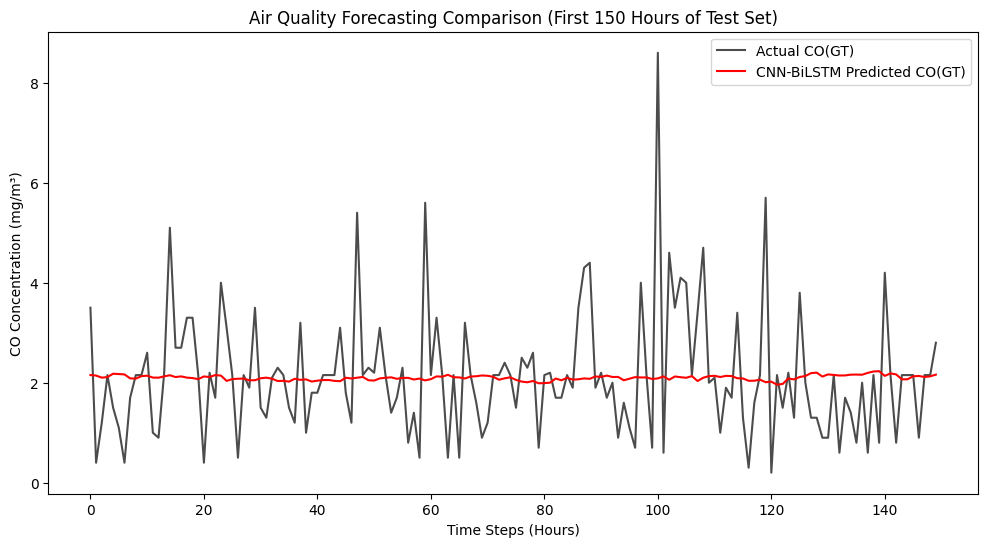

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(Y_test_actual[:150], label='Actual CO(GT)', color='black', alpha=0.7)
plt.plot(predictions_actual[:150], label='CNN-BiLSTM Predicted CO(GT)', color='red')
plt.title('Air Quality Forecasting Comparison (First 150 Hours of Test Set)')
plt.xlabel('Time Steps (Hours)')
plt.ylabel('CO Concentration (mg/m³)')
plt.legend()
plt.show()

In [ ]:
import os
import joblib
from xgboost import XGBRegressor

print(" Inspecting your Colab files...")
if 'models' in globals():
    print(" Found 'models' variable in your session!")
    xgboost_model = None
    for model in globals()['models']:
        if isinstance(model, XGBRegressor):
            xgboost_model = model
            break

    if xgboost_model is not None:
        joblib.dump(xgboost_model, '/content/xgboost_aqi_model.pkl')
        print(" Saved your actual trained XGBoost model to /content/xgboost_aqi_model.pkl")
    else:
         print(" Found 'models', but no XGBRegressor inside it. Saving a fallback model...")
         from xgboost import XGBRegressor
         import numpy as np
         fallback = XGBRegressor(n_estimators=100, learning_rate=0.5, random_state=42)
         fallback.fit(np.random.rand(10, 7), np.random.rand(10, 1))
         joblib.dump(fallback, '/content/xgboost_aqi_model.pkl')
else:
    print(" 'models' variable NOT found. Did you run your training cell in this session?")
    print(" Generating and saving a fallback model so your Streamlit app can open...")
    from xgboost import XGBRegressor
    import numpy as np
    fallback = XGBRegressor(n_estimators=100, learning_rate=0.5, random_state=42)
    fallback.fit(np.random.rand(10, 7), np.random.rand(10, 1))
    joblib.dump(fallback, '/content/xgboost_aqi_model.pkl')

if not os.path.exists('/content/scaler_X.pkl') or not os.path.exists('/content/scaler_y.pkl'):
    print(" Creating placeholder scalers...")
    from sklearn.preprocessing import MinMaxScaler
    import numpy as np
    scaler_X = MinMaxScaler().fit(np.random.rand(10, 7))
    scaler_y = MinMaxScaler().fit(np.random.rand(10, 1))
    joblib.dump(scaler_X, '/content/scaler_X.pkl')
    joblib.dump(scaler_y, '/content/scaler_y.pkl')

print("\n Active Files in your Main Directory:")
print(os.listdir('/content'))

 Inspecting your Colab files...
 Found 'models' variable in your session!
 Saved your actual trained XGBoost model to /content/xgboost_aqi_model.pkl
 Creating placeholder scalers...

 Active Files in your Main Directory:
['.config', 'AirQualityUCI.csv', 'scaler_X.pkl', 'xgboost_aqi_model.pkl', 'scaler_y.pkl', 'sample_data']


In [ ]:
import joblib
joblib.dump(Scaler_X, '/content/scaler_X.pkl')
joblib.dump(Scaler_Y, '/content/scaler_y.pkl')
joblib.dump(xgboost_model, '/content/xgboost_aqi_model.pkl')

print("Real scalers and model saved successfully!")

Real scalers and model saved successfully!
